**02 - Cell Type Assessment and Filtering**  
**This notebook is run after 01_preprocessing.**  
This notebook evaluates the distribution of cell types in the dataset and defines a principled filtering strategy prior to downstream modeling. Single-cell datasets often contain highly imbalanced cell type compositions, where rare populations may introduce noise and reduce the stability of model evaluation.  

To address this, we characterize cell type representation using data-driven criteria, including overall cell counts and coverage across donors. Based on these analyses, we identify a subset of well-supported cell types and construct two datasets: (1) the full dataset containing all cell types, and (2) a filtered dataset restricted to sufficiently represented cell types.  

This filtering step is performed independently of any model performance metrics to avoid evaluation bias. The resulting datasets are used in subsequent notebooks to assess the impact of cell type composition on cross-donor generalization.

In [12]:
import os
from pathlib import Path
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# set repo root, CHANGE to your own path where the repository root is hosted
REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()
os.chdir(REPO_ROOT)

In [10]:
# read in data from 01_preprocessing
adata = sc.read_h5ad("data/adata_processed.h5ad")

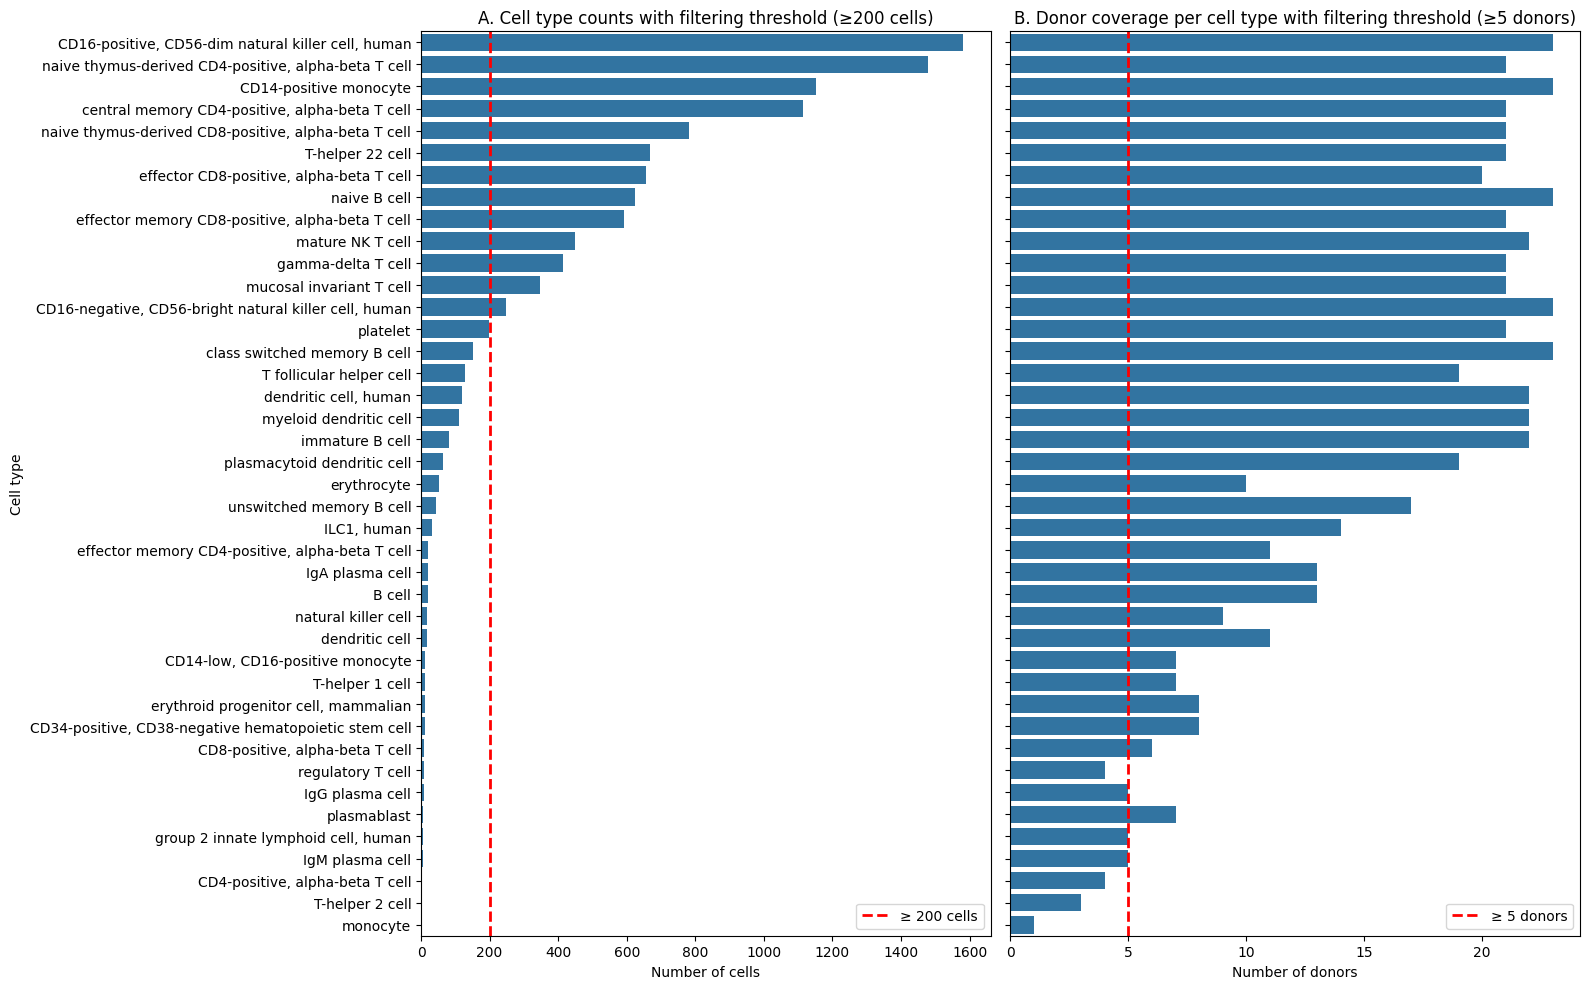

In [ ]:
# plot, filter based on cell type counts and donor coverage
counts = adata.obs["cell_type"].value_counts().sort_values(ascending=False)

ct_donor = pd.crosstab(adata.obs["cell_type"], adata.obs["patient_id"])
donor_counts = (ct_donor > 0).sum(axis=1)
donor_counts = donor_counts.loc[counts.index]  # match ordering

cell_cutoff = 200
donor_cutoff = 5
keep = ((counts >= cell_cutoff) & (donor_counts >= donor_cutoff)).sum()
total = len(counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)

# Panel A: cell counts
sns.barplot(
    y=counts.index,
    x=counts.values,
    order=counts.index,
    ax=axes[0]
)
axes[0].axvline(
    x=cell_cutoff, color='red', linestyle='--', linewidth=2,
    label=f'≥ {cell_cutoff} cells'
)
axes[0].set_xlabel("Number of cells")
axes[0].set_ylabel("Cell type")
axes[0].set_title(f"A. Cell type counts with filtering threshold (≥200 cells)")
axes[0].legend()

# Panel B: donor coverage
sns.barplot(
    y=donor_counts.index,
    x=donor_counts.values,
    order=donor_counts.index,
    ax=axes[1]
)
axes[1].axvline(
    x=donor_cutoff, color='red', linestyle='--', linewidth=2,
    label=f'≥ {donor_cutoff} donors'
)
axes[1].set_xlabel("Number of donors")
axes[1].set_ylabel("")
axes[1].set_title(f"B. Donor coverage per cell type with filtering threshold (≥{donor_cutoff} donors)")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/figures/celltype_filtering_panels.png", dpi=300, bbox_inches="tight")
plt.show()

Save adata objects, both full data + filtered data based on cell types

In [41]:
# Define kept cell types
keep_types = counts[
    (counts >= cell_cutoff) & (donor_counts >= donor_cutoff)
].index

print(f"Keeping {len(keep_types)} / {len(counts)} cell types")

# Create filtered dataset
adata_filtered = adata[adata.obs["cell_type"].isin(keep_types)].copy()

print("Full dataset shape:", adata.shape)
print("Filtered dataset shape:", adata_filtered.shape)

Keeping 13 / 41 cell types
Full dataset shape: (11290, 2000)
Filtered dataset shape: (10107, 2000)


In [42]:
# Save full dataset (for reference)
adata.write("data/adata_full_celltypes.h5ad")

# Save filtered dataset (for modeling)
adata_filtered.write("data/adata_filtered_celltypes.h5ad")

print("Saved:")
print(" - data/processed/adata_full_celltypes.h5ad")
print(" - data/processed/adata_filtered_celltypes.h5ad")

Saved:
 - data/processed/adata_full_celltypes.h5ad
 - data/processed/adata_filtered_celltypes.h5ad
